Lab 4 - Data Preprocessing on StudentPerformanceFactors Dataset

Import & Load Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files
uploaded = files.upload()

df = pd.read_csv('StudentPerformanceFactors.csv')
df.head()

Saving StudentPerformanceFactors.csv to StudentPerformanceFactors.csv


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


Task 1: Identify Data Quality Issues

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [ ]:
df.isnull().sum()

,0
Hours_Studied,0
Attendance,0
Parental_Involvement,0
Access_to_Resources,0
Extracurricular_Activities,0
Sleep_Hours,0
Previous_Scores,0
Motivation_Level,0
Internet_Access,0
Tutoring_Sessions,0


In [ ]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.dtypes

,0
Hours_Studied,int64
Attendance,int64
Parental_Involvement,object
Access_to_Resources,object
Extracurricular_Activities,object
Sleep_Hours,int64
Previous_Scores,int64
Motivation_Level,object
Internet_Access,object
Tutoring_Sessions,int64


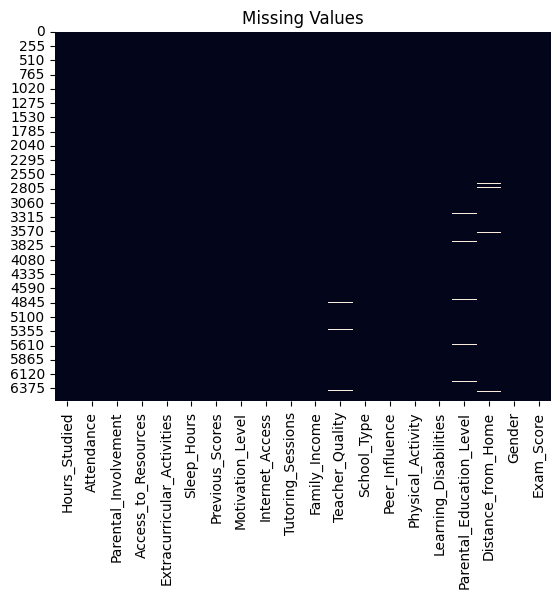

In [ ]:
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values")
plt.show()

In this step, we explored the dataset to identify potential data quality issues. We checked the structure of the data using info(), examined missing values, and looked for duplicate records. We also reviewed the data types of each column to ensure they are appropriate. This step is important because understanding the dataset helps us prepare it correctly before applying any preprocessing or machine learning techniques.



 Task 2: Handle Missing Values

In [ ]:
num_cols = df.select_dtypes(include=np.number).columns

df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

In [ ]:
df.isnull().sum()

,0
Hours_Studied,0
Attendance,0
Parental_Involvement,0
Access_to_Resources,0
Extracurricular_Activities,0
Sleep_Hours,0
Previous_Scores,0
Motivation_Level,0
Internet_Access,0
Tutoring_Sessions,0


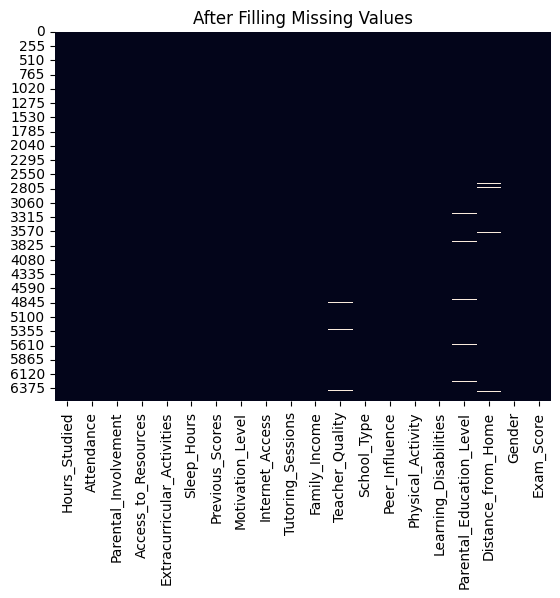

In [ ]:
sns.heatmap(df.isnull(), cbar=False)
plt.title("After Filling Missing Values")
plt.show()

In this task, we handled missing values using mean imputation. Instead of removing rows with missing values, we replaced them with the average value of each numerical column. This approach helps us preserve the dataset size and prevents losing important information. Mean imputation is simple and effective, especially when the data is not highly skewed.

Task 3: Detect & Handle Outliers (IQR)

In [ ]:
num_cols = df.select_dtypes(include=np.number).columns
col = num_cols[0]
print("Selected column:", col)

Selected column: Hours_Studied


In [ ]:
Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 16.0
Q3: 24.0
IQR: 8.0
Lower Bound: 4.0
Upper Bound: 36.0


In [ ]:
outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
print("Number of outliers:", outliers.shape[0])
outliers.head()

Number of outliers: 43


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
209,43,86,High,Medium,Yes,7,97,Medium,Yes,2,Medium,High,Public,Positive,1,No,High School,Near,Female,78
262,1,69,High,Medium,Yes,6,97,Medium,Yes,1,Low,Medium,Public,Positive,3,No,High School,Near,Female,61
478,38,86,Low,High,Yes,7,79,Low,Yes,3,Low,Medium,Public,Negative,3,No,High School,Near,Male,73
1061,3,85,Low,High,No,8,73,Low,Yes,2,Low,Medium,Private,Neutral,3,No,High School,Near,Male,62
1101,3,62,Medium,Low,No,6,67,Medium,Yes,1,Low,Medium,Public,Negative,3,No,High School,Near,Male,55


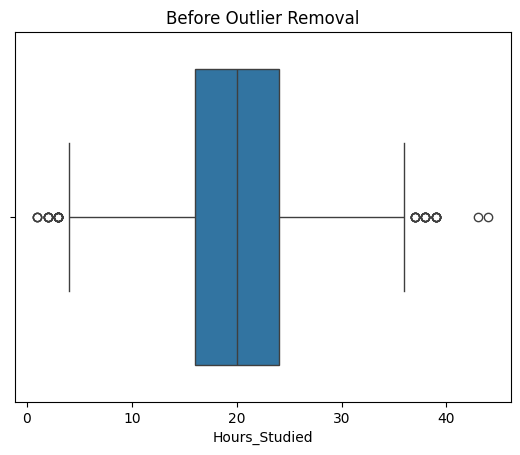

In [ ]:
sns.boxplot(x=df[col])
plt.title("Before Outlier Removal")
plt.show()

In [ ]:
df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

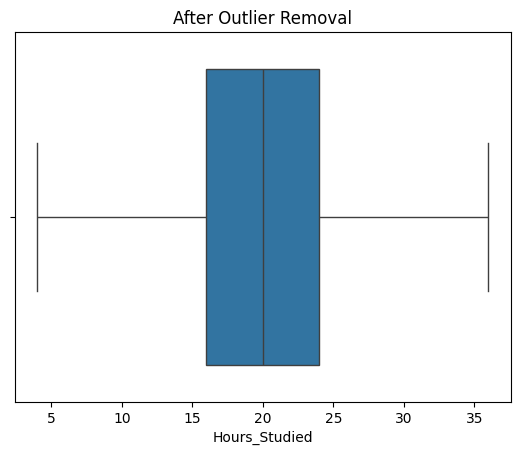

In [ ]:
sns.boxplot(x=df[col])
plt.title("After Outlier Removal")
plt.show()

In this task, we selected a numerical column and applied the IQR method to detect outliers. We calculated Q1, Q3, and IQR, then determined the lower and upper bounds. After identifying the outliers, we visualized the data using a boxplot before and after removing them. This helped improve the data quality by eliminating extreme values.

Task 4: Normalization

Select numerical features

In [ ]:
numerical_features = df.select_dtypes(include=np.number).columns.tolist()
print(numerical_features)

['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity', 'Exam_Score']


Min-Max Normalization

In [ ]:
from sklearn.preprocessing import MinMaxScaler

minmax_scaler = MinMaxScaler()

df_minmax = df.copy()
df_minmax[numerical_features] = minmax_scaler.fit_transform(df[numerical_features])

df_minmax[numerical_features].head()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
0,0.59375,0.600,0.500000,0.46,0.000,0.500000,0.244444
1,0.46875,0.100,0.666667,0.18,0.250,0.666667,0.111111
2,0.62500,0.950,0.500000,0.82,0.250,0.666667,0.400000
3,0.78125,0.725,0.666667,0.96,0.125,0.666667,0.333333
4,0.46875,0.800,0.333333,0.30,0.375,0.666667,0.311111


Z-score Standardization

In [ ]:
from sklearn.preprocessing import StandardScaler

zscore_scaler = StandardScaler()

df_zscore = df.copy()
df_zscore[numerical_features] = zscore_scaler.fit_transform(df[numerical_features])

df_zscore[numerical_features].head()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
0,0.520049,0.350435,-0.020039,-0.144552,-1.212233,0.030894,-0.058920
1,-0.166309,-1.382663,0.661503,-1.116652,0.411002,1.001169,-1.616298
2,0.691638,1.563604,-0.020039,1.105291,0.411002,1.001169,1.758022
3,1.549585,0.783710,0.661503,1.591341,-0.400616,1.001169,0.979333
4,-0.166309,1.043674,-0.701582,-0.700038,1.222620,1.001169,0.719769


In this task, we applied normalization techniques to the dataset. First, Min-Max scaling was used to transform the values into a range between 0 and 1. Then, Z-score standardization was applied to center the data around the mean with a standard deviation of 1. These techniques help improve model performance by ensuring that all numerical features are on a similar scale.

Task 5

 Principal Component Analysis (PCA)

In [ ]:
from sklearn.preprocessing import LabelEncoder

cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

In [ ]:
df.dtypes

,0
Hours_Studied,int64
Attendance,int64
Parental_Involvement,int64
Access_to_Resources,int64
Extracurricular_Activities,int64
Sleep_Hours,int64
Previous_Scores,int64
Motivation_Level,int64
Internet_Access,int64
Tutoring_Sessions,int64


In [ ]:
numerical_features = df.select_dtypes(include=np.number).columns.tolist()
print(numerical_features)

['Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours', 'Previous_Scores', 'Motivation_Level', 'Internet_Access', 'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender', 'Exam_Score']


In [ ]:
corr_matrix = df[numerical_features].corr()
corr_matrix

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
Hours_Studied,1.000000,-0.011009,0.010231,-0.007460,-0.001737,0.010724,0.019668,0.024240,0.008469,-0.014115,0.010088,0.007080,0.000265,0.011002,0.002855,-0.014495,0.014404,-0.014165,-0.003406,0.437572
Attendance,-0.011009,1.000000,-0.002337,0.001593,-0.003061,-0.017882,-0.019708,0.013572,-0.020155,0.012522,-0.008621,-0.009031,-0.018913,-0.007300,-0.022828,-0.021685,0.014313,0.015465,0.008281,0.584579
Parental_Involvement,0.010231,-0.002337,1.000000,0.010776,0.023264,0.001244,0.005947,-0.013207,0.001856,-0.005963,0.006413,-0.006325,-0.003731,-0.008007,0.008571,-0.011175,0.019311,-0.003779,0.022023,-0.092740
Access_to_Resources,-0.007460,0.001593,0.010776,1.000000,-0.008337,-0.002441,-0.002888,-0.012675,0.001115,0.013351,0.010034,0.012397,0.029949,0.007688,0.037279,0.004433,-0.006876,0.013483,0.007278,-0.088983
Extracurricular_Activities,-0.001737,-0.003061,0.023264,-0.008337,1.000000,0.000841,0.005087,-0.007569,-0.004458,0.003284,0.014451,-0.004868,0.005256,0.009074,-0.001036,-0.008279,-0.014366,-0.012218,0.008323,0.065515
Sleep_Hours,0.010724,-0.017882,0.001244,-0.002441,0.000841,1.000000,-0.020315,-0.000193,0.012015,-0.013253,0.010384,-0.007072,0.002619,-0.017608,-0.000691,0.015376,-0.006768,0.001467,-0.008079,-0.016435
Previous_Scores,0.019668,-0.019708,0.005947,-0.002888,0.005087,-0.020315,1.000000,-0.022174,0.005065,-0.013935,0.012529,-0.017882,0.011895,-0.016547,-0.008723,0.006812,0.008956,0.004239,0.003982,0.174719
Motivation_Level,0.024240,0.013572,-0.013207,-0.012675,-0.007569,-0.000193,-0.022174,1.000000,0.001545,-0.011393,-0.009872,0.012195,-0.006383,0.003061,-0.005409,-0.018417,0.014735,0.016754,0.003357,-0.011830
Internet_Access,0.008469,-0.020155,0.001856,0.001115,-0.004458,0.012015,0.005065,0.001545,1.000000,-0.010133,0.016955,-0.001270,0.012647,-0.011897,-0.012754,0.006780,0.026408,-0.010769,0.013948,0.052290
Tutoring_Sessions,-0.014115,0.012522,-0.005963,0.013351,0.003284,-0.013253,-0.013935,-0.011393,-0.010133,1.000000,-0.002437,-0.001624,0.008537,-0.004411,0.018615,0.007614,-0.005470,0.016141,-0.006195,0.155898


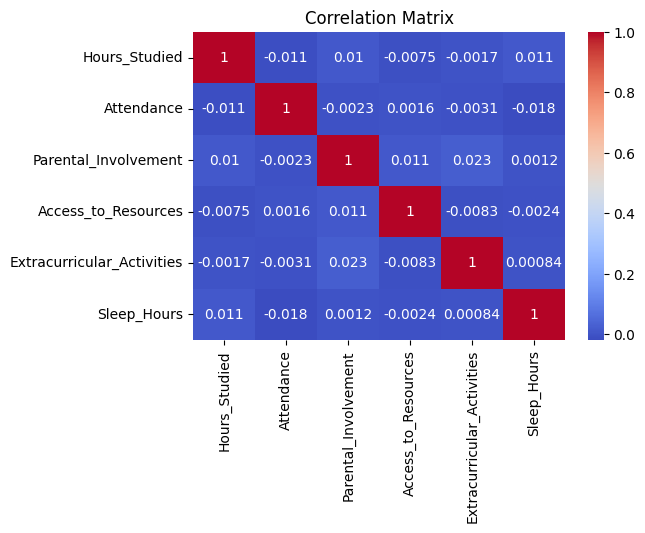

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

selected_cols = numerical_features[:6]

corr_matrix = df[selected_cols].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [ ]:
from sklearn.decomposition import PCA

pca = PCA()
pca_data = pca.fit_transform(df[numerical_features])

In [ ]:
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [5.19856859e-01 3.46505288e-01 9.30334193e-02 1.43928159e-02
 5.37742626e-03 3.53263045e-03 2.66363339e-03 2.06831672e-03
 1.86444498e-03 1.81072156e-03 1.52887101e-03 1.38104962e-03
 1.36812227e-03 1.35145662e-03 1.13236319e-03 6.10440739e-04
 5.90125800e-04 5.26999452e-04 2.32978991e-04 1.72037187e-04]


In this task, categorical features were converted into numerical values using Label Encoding to make them suitable for analysis. Then, correlation between features was calculated and visualized using a heatmap to identify relationships between variables. Since correlation existed, PCA was applied to reduce the number of features while preserving most of the important information. The explained variance ratio shows how much information each component retains.

 Apply PCA

In [ ]:
clean_data = df_zscore[numerical_features].dropna()

In [ ]:
from sklearn.preprocessing import LabelEncoder

cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

In [ ]:
from sklearn.preprocessing import StandardScaler

numerical_features = df.select_dtypes(include=np.number).columns

scaler = StandardScaler()
df_zscore = df.copy()
df_zscore[numerical_features] = scaler.fit_transform(df[numerical_features])

In [ ]:
df_zscore[numerical_features].head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,0.520049,0.350435,-0.255317,-1.382384,-1.214542,-0.020039,-0.144552,-0.393864,0.286214,-1.212233,-0.284096,0.743438,0.66031,1.070187,0.030894,-0.34412,0.103612,0.716322,0.855527,-0.058920
1,-0.166309,-1.382663,-0.255317,0.912790,-1.214542,0.661503,-1.116652,-0.393864,0.286214,0.411002,1.062335,0.743438,0.66031,-1.578646,1.001169,-0.34412,-1.248491,-0.743907,-1.168870,-1.616298
2,0.691638,1.563604,0.900477,0.912790,0.823355,-0.020039,1.105291,0.884734,0.286214,0.411002,1.062335,0.743438,0.66031,-0.254230,1.001169,-0.34412,1.455714,0.716322,0.855527,1.758022
3,1.549585,0.783710,-0.255317,0.912790,0.823355,0.661503,1.591341,0.884734,0.286214,-0.400616,1.062335,0.743438,0.66031,-1.578646,1.001169,-0.34412,0.103612,-0.743907,0.855527,0.979333
4,-0.166309,1.043674,0.900477,0.912790,0.823355,-0.701582,-0.700038,0.884734,0.286214,1.222620,1.062335,-1.449295,0.66031,-0.254230,1.001169,-0.34412,-1.248491,0.716322,-1.168870,0.719769


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_zscore[numerical_features])

In [ ]:
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.09004634 0.05441562]


Explained Variance Ratio: [0.09004634 0.05441562]


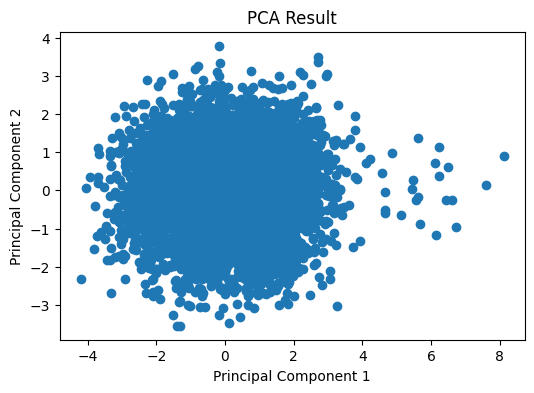

In [ ]:
pca_df = pd.DataFrame(pca_result, columns=['PC1', 'PC2'])

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.scatter(pca_df['PC1'], pca_df['PC2'])
plt.title("PCA Result")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

The correlation matrix showed generally weak relationships between most of the numerical features in the dataset. Although some minor correlations may exist, they are not strong enough to indicate significant dependency between variables. PCA was still applied to reduce the data into two principal components as required in this task. However, due to the low correlation among features, the effectiveness of PCA in reducing dimensionality is limited. The explained variance ratio indicates that the selected components capture only part of the total variance, meaning that important information is still distributed across multiple features.
